## HoldOut Feature Selection

We tested different ways of performing feature selection. 

First, we used a single data split (hold-out). We decided to keep this approach, only in this separate notebook, as we believe it was correctly applied. Even though it is incomplete, since it uses recursive feature selection (RFE) as the only method of feature selection, it still provided a minor insight into the next RFE applied in the cross-validation approach.

As pipelines started being used, it seemed logical to apply a more reliable approach, and so cross-validation was implemented within them. The reasons for choosing this method are presented in its corresponding section.

As stated before, the hold-out section is presented in this notebook.

# Import Packages

In [1]:
import os
import pandas as pd
import numpy as np

## Read Data and Inspect

In [2]:
#importing original data and previously worked dataframe
df_train = pd.read_csv("../project_data/handout_data/training_handout.csv")

In [3]:
df_train.columns

Index(['Unnamed: 0', 'carID', 'brand', 'model', 'price', 'transmission',
       'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'paintQuality%',
       'previousOwners', 'hasDamage', 'car_age'],
      dtype='object')

In [4]:
df_train.shape

(75973, 15)

In [5]:
#remove unnamed 0 column
df_train = df_train.drop(columns=['Unnamed: 0'])
df_train

,carID,brand,model,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,car_age
0,69512,vw,golf,22290,semi-auto,28421.0,petrol,NaN,11.4,2.0,63.0,4.0,0.0,4.0
1,53000,toyota,yaris,13790,manual,4589.0,petrol,145.0,47.9,1.5,50.0,1.0,0.0,1.0
2,6366,audi,q2,24990,semi-auto,3624.0,petrol,145.0,40.9,1.5,56.0,4.0,0.0,1.0
3,29021,ford,fiesta,12500,manual,9102.0,petrol,145.0,65.7,1.0,50.0,NaN,0.0,2.0
4,10062,bmw,2 series,22995,manual,1000.0,petrol,145.0,42.8,1.5,97.0,3.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,37194,mercedes,c class,13498,manual,14480.0,petrol,125.0,53.3,2.0,78.0,0.0,0.0,5.0
75969,6265,audi,q3,12495,semi-auto,52134.0,diesel,200.0,47.9,2.0,38.0,2.0,0.0,7.0
75970,54886,toyota,aygo,8399,automatic,11304.0,petrol,145.0,67.0,1.0,57.0,3.0,0.0,3.0
75971,860,audi,q3,12990,manual,69072.0,diesel,125.0,60.1,2.0,74.0,2.0,0.0,5.0


The missing data imputation will be mainly made through the brand feature. Due to that and to the fact that the instances where there is no information about the brand represent 0.06% of the total data, these lines will be dropped.

In [7]:
df_train = df_train[~df_train["brand"].isnull()]
df_train

,carID,brand,model,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,car_age
0,69512,vw,golf,22290,semi-auto,28421.0,petrol,NaN,11.4,2.0,63.0,4.0,0.0,4.0
1,53000,toyota,yaris,13790,manual,4589.0,petrol,145.0,47.9,1.5,50.0,1.0,0.0,1.0
2,6366,audi,q2,24990,semi-auto,3624.0,petrol,145.0,40.9,1.5,56.0,4.0,0.0,1.0
3,29021,ford,fiesta,12500,manual,9102.0,petrol,145.0,65.7,1.0,50.0,NaN,0.0,2.0
4,10062,bmw,2 series,22995,manual,1000.0,petrol,145.0,42.8,1.5,97.0,3.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,37194,mercedes,c class,13498,manual,14480.0,petrol,125.0,53.3,2.0,78.0,0.0,0.0,5.0
75969,6265,audi,q3,12495,semi-auto,52134.0,diesel,200.0,47.9,2.0,38.0,2.0,0.0,7.0
75970,54886,toyota,aygo,8399,automatic,11304.0,petrol,145.0,67.0,1.0,57.0,3.0,0.0,3.0
75971,860,audi,q3,12990,manual,69072.0,diesel,125.0,60.1,2.0,74.0,2.0,0.0,5.0


#### Removing Features Previously Identified as irrelavant in EDA

In [8]:
df_train = df_train.drop(columns=['carID', 'previousOwners', 'paintQuality%', 'hasDamage'])

In [9]:
df_train.columns

Index(['brand', 'model', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize', 'car_age'],
      dtype='object')

## Split the data

In [10]:
X = df_train.drop("price", axis=1).copy()
y = df_train["price"].copy()

## Pipeline construction

### Column Transformers

In [37]:
class RareLabelGrouper(BaseEstimator, TransformerMixin):
    
    """
    This class will be useful to identify and group rare instances in the model column as "other". 
    The minimal proportion needed to not be grouped is min_prop.
    
    """
   
    def __init__(self, min_prop=0.005, column=None): 
        self.min_prop = min_prop
        
        self.column = column
        
        self.keep_values_ = None  #This will be used to store the values to group
    
    
    def fit(self, X, y=None):
        s = X if isinstance(X, pd.Series) else pd.Series(X.iloc[:,0] if hasattr(X, "iloc") else X[:,0])  # 
        
        vc = s.value_counts(dropna=False) 
        
        total = len(s)  
        
        keep = vc[vc / total >= self.min_prop].index # Chooses the categories for which the minimum proportion is met
        
        self.keep_values_ = set(keep.tolist()) # Attributes them to an attribute of the class in the form of a list
        
        return self
    
    
    def transform(self, X):
        """
        np.where() works like an if-else statement. If s is in stored values to keep, then keep s, else attribute "Other".
        To attribute the name of the column, if it was passed and stored in the attribute .column, then use that name, else use the generic 'col' name.
        """
        s = X if isinstance(X, pd.Series) else pd.Series(X.iloc[:,0] if hasattr(X, "iloc") else X[:,0])  #Same pandas series problem
        return pd.DataFrame(np.where(s.isin(self.keep_values_), s, "Other"),  
                            columns=[self.column if self.column else "col"])

    
    def get_feature_names_out(self, input_features=None):

        if input_features is not None:
            return np.asarray(input_features, dtype=object)

        col_name = self.column if self.column else "col"
        return np.asarray([col_name], dtype=object)


In [39]:
class Mode_Imput_By_Brand (BaseEstimator, TransformerMixin):

    """
    O objetivo com este transformer é preencher os valores nulos de cada coluna através da moda, mas primeiro, agrupar por brand.
    Como fallback, caso nao haja nenhuma linha preenchida daquela brand em especifico, depois de utilizar este transformer
    iremos utilzar o SimpleImputer.
    
    """
    
    def __init__(self, imput_cols = None , group_col = "brand"):       
        self.imput_cols = imput_cols  #Store the imputing values for each group
        self.group_col = group_col #Stores the variable name in which we want to group to input the value we need (for example, group by the brand to input the most likely model of a given car)

    # é obrigatorio colocar X e y em todos os metodos de fit do sklearn
    def fit(self , X, y = None):
        X = X.copy()  # em qualquer metodo do sklearn criamos uma copia do df original, pois no pipeline é usado o mesmo df nao modificado para os vários passos
        
        if self.imput_cols is None: # sklearn nao gosta de args obrigatórios entao fazemos isto para contornar
            self.imput_cols = [col for col in X.columns if col != self.group_col] #Iterates over all columns that are not group_col and stores their names in a list 
        
        self.mode_maps_ = {}

        for col in self.imput_cols:  #Iterate over all columns except the group_col
            mode_map = X.groupby(self.group_col)[col].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)  #Calculates the mode for each group and if there isn't assume np.nan
            self.mode_maps_[col] = mode_map

        return self

        
    def transform(self, X):
        X = X.copy()

        for col in self.imput_cols:  #Iterate over all columns except the group_col
            X[col] = X[col].fillna(X[self.group_col].map(self.mode_maps_[col]))  #Fills all nans in one column (col) with the mode found in the mode_maps_ dict, which contains the mode for the different groups that were grouped through the group_col

        return X

In [40]:
class Imput_By_Brand_and_Model (BaseEstimator, TransformerMixin):

    """

    The goal with this transformer is to fullfill the Nans by the mode,  but 1st grouping by brand and model. Has a fallback
    in the pipeline, after using this transformer, it should be used a SimplImputer to guarantee that in the end, there is no missing
    values.

    =============================================================================================================================

    Parameters:

        imput_cols: List of cols you want to imput, if none is passed then it will assume all columns should be imputed besides the 
        ones on the group_cols

        group_cols: List of cols you want to groupby, it's defaulted to be brand and model

        .mode_maps: Dictionary for each imput column, where each key is an imput_col and each value is a dictionary where each key is
                    a combiantion of brand and model and each value is the mode

    ==============================================================================================================================

    Methods:
    
        .fit: Creates a loop that for each column to imput: 0. Creates an empty dict to store each imput col as a key
                                                            1. Groups the data by the group_cols
                                                            2. Calculates the mode, if more than 1 get´s the 1st one 
                                                            if there is no value it returns Nan
                                                            3. Stores the combination of brand and model (group_cols) and mode
                                                            as a key-value pair 
        
        .transform: 1. For each row of the dataset stores the pair of (brand,model) into a Series
                    2. Loops trough the imput_cols and for each one it uses the pairs created before as a key to get the value of 
                    the mode_maps, storing this value in a Series called mapped
                    3. Goes trough each line of the data, if the value is nan it fulfiles it with the corresponding value of the
                    mapped series

    ==============================================================================================================================

    Attributes:

        mode_maps_ : Dictionary of dictionarys that stores the mode for each pair in each column of X.

                     {{"feature_1:"("bmw","i8"): mode,
                     ('vw', 'up!'): mode},
                     {"feature_2": "("bmw","i8"): mode,
                     ('vw', 'up!'): mode}}
                     
    
    """

    def __init__(self, imput_cols = None , group_cols = ["brand", "model"]):       
        self.imput_cols = imput_cols
        self.group_cols = group_cols

    
    def fit(self , X, y = None):
        X = X.copy()  
        
        if self.imput_cols is None: 
            self.imput_cols = [col for col in X.columns if col != self.group_cols]
        
        self.mode_maps_ = {}

        for col in self.imput_cols:
            mode_map = X.groupby(self.group_cols)[col].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan) 
            self.mode_maps_[col] = mode_map.to_dict()

        return self 
    
    def transform(self, X):
        X = X.copy()

        keys = list(zip(*[X[g] for g in self.group_cols]))  # [(brand, model), ...]
        key_series = pd.Series(keys, index=X.index)

        for col in self.imput_cols:
            mapped = key_series.map(self.mode_maps_[col])
            X[col] = X[col].fillna(mapped)

        return X

In [41]:
class Log1pSkewed(BaseEstimator, TransformerMixin):
    """ 
    This transformer computes the natural logarithm of (1 + x) for the columns specified in log_candidates. 
    The goal is to reduce right-skewness and stabilise variance in those features.
     ========================================================================================================

    Parameters: 
        numeric_cols: list of str
                      Names of the numeric columns of X
        log_candidates: list of str
                        Names of the columns of X that are right_skewed
     ========================================================================================================

    Methods:
        .fit: Stores the name of all features the indices of the features that will
        undergo through the log1p transformation (log_candidates).
        .transform: Applies the log1p transformation to the selected columns.
        .get_feature_names_out:        
    ========================================================================================================

    Attributes:

        n_features_in_: number of features before applying the fit
        feature_names_in_: name of the features before applying the fit
        log_idx_: indices of the columns in log_candidates
    """
    
    def __init__(self, numeric_cols, log_candidates):
        self.numeric_cols = numeric_cols
        self.log_candidates = log_candidates

    def fit(self, X, y=None):  
        #X = validate_data(self, X, accept_sparse=False, reset=True) # guarantees a correct format and stores n_features_in_
        #X = self._validate_data(X, accept_sparse=False, reset=True, force_all_finite='allow-nan') # guarantees a correct format and stores n_features_in_
        if hasattr(X, "columns"): # here the intention is to give more flexibility, on the current pipeline, we know that it will receive an array.
            self.feature_names_in_ = np.array(X.columns, dtype=object) 
        else:
            self.feature_names_in_ = np.array(self.numeric_cols, dtype=object)
        self.log_idx_ = [self.numeric_cols.index(c) for c in self.log_candidates]
        return self

    
    def transform(self, X):        
        X = np.asarray(X).copy() # turn X into an array just in case       
        X[:, self.log_idx_] = np.log1p(X[:, self.log_idx_])        
        return X

    
    def get_feature_names_out(self, input_features=None):
        
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        
        elif hasattr(self, "feature_names_in_"): # just in case this is the 1st transformer, even tough it probably never will
            return self.feature_names_in_ 

### Implementation

In [46]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]
without_model = [c for c in X.columns if c not in numeric_cols + ['model']]
without_model_brand = [c for c in X.columns if c not in ["model", "brand"]]
log_candidates = ['mpg', 'car_age', 'mileage', 'engineSize', 'tax']

In [47]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p_skewed", Log1pSkewed(numeric_cols, log_candidates)),  
    ("scaler", StandardScaler())
])

In [48]:
cats = []
cats.append(("cat",
                 Pipeline([("fallback_impute", SimpleImputer(strategy="most_frequent")),
                           ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))]),
                without_model))
cats.append(("model_collap",
                 Pipeline([("fallback_impute", SimpleImputer(strategy="most_frequent")),
                           ("rare", RareLabelGrouper(min_prop=0.005, column="model")),
                           ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))]),
                  ["model"] ))

In [49]:
preprocessor = ColumnTransformer([("num", numeric_pipeline, numeric_cols), *cats])
pipe_preprocessor = Pipeline([("Imput_model_mode_grouped", Mode_Imput_By_Brand(imput_cols=["model"], group_col="brand")),
                              ("Imput_overal_mode_grouped_by_brand_and_model", Imput_By_Brand_and_Model(imput_cols = without_model_brand)),
                              ("column_transformer",preprocessor)])

In [50]:
pipe_preprocessor

Pipeline(steps=[('Imput_model_mode_grouped',
                 Mode_Imput_By_Brand(imput_cols=['model'])),
                ('Imput_overal_mode_grouped_by_brand_and_model',
                 Imput_By_Brand_and_Model(imput_cols=['tax', 'mpg',
                                                      'engineSize',
                                                      'car_age'])),
                ('Imput_overal_mode_grouped_by_brand',
                 Imput_By_Brand_and_Model(group_cols=['brand'],
                                          imput_cols=['tax', 'mpg',
                                                      'engineSize',
                                                      'car_age'])),
                ('impu...
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['brand', 'transmission',
                                                   'fuelType']),
                                                 ('model_collap',
                                                  Pipeline(steps=[('fallback_impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('rare',
                                                                   RareLabelGrouper(column='model')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['model'])]))])

In [36]:
pipe_preprocessor.fit(X)
n_total = pipe_preprocessor.transform(X).shape[1]

In [37]:
# this indicates us the amount of features obtained to then uset it as max in the rfe
n_total

65

### Feature Selection using HoldOut

Following initial data preprocessing steps, which included the removal of several irrelevant columns, we employed Recursive Feature Elimination (RFE) to determine the optimal feature subset for a linear regression model. 

A holdout validation approach was utilized to evaluate model performance with varying numbers of features, using the Mean Absolute Error (MAE) as the primary evaluation metric.

In [131]:
#Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=44
)

In [132]:
grid = np.arange(1,n_total+1)

In [133]:
# Create variables to store the records for training and validation
records = []
best_model = None
high_score = None
n_feat = 0
selected_features = None

In [134]:
for n_sel in grid:
    model = LinearRegression()
    pipe = Pipeline([
        ("prep", pipe_preprocessor),
        ("rfe", RFE(estimator=model, n_features_to_select=n_sel)),
        ("linreg", LinearRegression()),
    ])
    
    pipe.fit(X_train, y_train) 

    # results of training dataset
    train_pred = pipe.predict(X_train)
    train_mae = mean_absolute_error(y_train, train_pred)

    # results of validation dataset
    val_pred = pipe.predict(X_val)
    val_mae = mean_absolute_error(y_val, val_pred)

    # append both records to then plot
    records.append({"n_selected": n_sel,
    "train_MAE": train_mae,
    "val_MAE": val_mae})

    if (high_score is None) or (val_mae < high_score):
        high_score = val_mae
        best_model = pipe
        n_feat = n_sel

In [135]:
# Checking the scores for each iteration
records

[{'n_selected': 1,
  'train_MAE': 6902.665965731732,
  'val_MAE': 6958.430076895673},
 {'n_selected': 2,
  'train_MAE': 6831.988560079867,
  'val_MAE': 6885.627928657042},
 {'n_selected': 3,
  'train_MAE': 5608.9157521830175,
  'val_MAE': 5656.850072663291},
 {'n_selected': 4,
  'train_MAE': 3772.042054390681,
  'val_MAE': 3817.4013214115225},
 {'n_selected': 5,
  'train_MAE': 3588.362662031176,
  'val_MAE': 3619.081379241605},
 {'n_selected': 6,
  'train_MAE': 3556.092380988909,
  'val_MAE': 3589.5333268891573},
 {'n_selected': 7,
  'train_MAE': 3530.5990847983353,
  'val_MAE': 3570.6793539390774},
 {'n_selected': 8,
  'train_MAE': 3501.4700191809643,
  'val_MAE': 3546.0762221580567},
 {'n_selected': 9,
  'train_MAE': 3468.4994178458383,
  'val_MAE': 3509.4205207046107},
 {'n_selected': 10,
  'train_MAE': 3401.1211016105362,
  'val_MAE': 3434.2227639007947},
 {'n_selected': 11,
  'train_MAE': 3396.2301982115528,
  'val_MAE': 3429.1382060153383},
 {'n_selected': 12,
  'train_MAE': 3391

In [136]:
# extract to list to then plot
train_score_list = [record["train_MAE"] for record in records]
val_score_list = [record["val_MAE"] for record in records]

len(val_score_list)

65

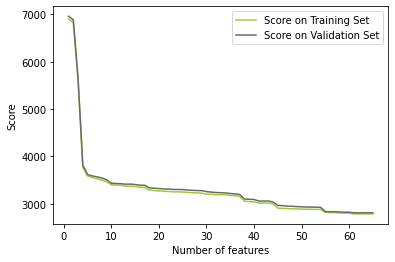

Lowest score of MAE is with number of features: 64
Score with 64 features: 2811.032042


In [137]:
plt.plot(list(range(1,66)), train_score_list, label="Score on Training Set", color='yellowgreen')
plt.plot(list(range(1,66)), val_score_list, label="Score on Validation Set", color='dimgray')
plt.xlabel("Number of features")
plt.ylabel("Score")
plt.legend()
plt.show()

print("Lowest score of MAE is with number of features: %d" %n_feat)
print("Score with %d features: %f" % (n_feat, high_score))

- Altough the lowest score is with 64 features, we can say that using the Linear Regression with the RFE, the model reaches his plateu at 55 features.
- The model does not seem to be overfitting neither underfitting, since  the difference on training and validation score is very low.
- The MAE got lower as we increased the number of features, however the error is still high with 2.8k, wich may indicate that the relathionship between X and Y is not that linear.